In [2]:
import qsample as qs
import time
import stim
import numpy as np
import matplotlib.pyplot as plt
import pymatching

/Users/jhfontes/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


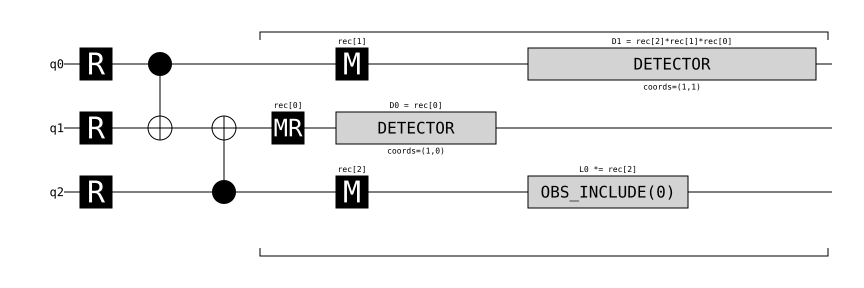

In [3]:
code = stim.Circuit.generated("repetition_code:memory", rounds=1, distance=2)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

code.diagram('timeline-svg')

p=('1.00e-03',): 100%|██████████| 20000/20000 [00:01<00:00, 13328.25it/s]


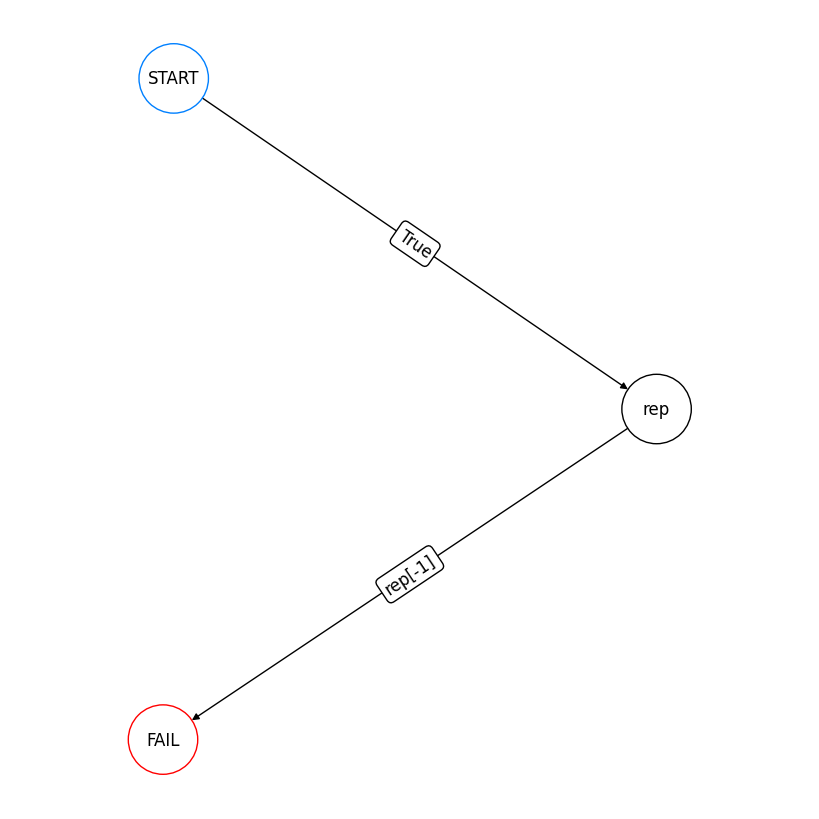

In [4]:
distance = 5
code = stim.Circuit.generated("repetition_code:memory", rounds=1, distance=distance, before_round_data_depolarization=0.01,
              before_measure_flip_probability=0.01)
rep_code = qs.Circuit(noisy=True).from_stim_circuit(code)

DEM = code.detector_error_model(decompose_errors=True)
decoder = pymatching.Matching.from_detector_error_model(DEM)




functions = {}
rep = qs.Protocol(check_functions=functions)


rep.add_nodes_from(['rep'], circuits=[rep_code])
rep.add_edge('START', 'rep', check='True')
rep.add_edge('rep', 'FAIL', check='rep[-1]')

rep.draw(figsize=(8,8), path='protocol_surface')

err_model = qs.noise.E1
stim_sam = qs.SplittingSampler(20000, protocol=rep, simulator=qs.StimSimulator,  p_max={'q': [0.001]}, err_model=err_model, distance=distance)
#stim_sam = qs.SplittingSampler(protocol=steane0, simulator=qs.StimSimulator,  err_model=err_model, err_params=err_params)
#stim_sam.run(1e-4)

In [5]:
begin_time = time.time()
p_l = []
for i in range(10):
    stim_sam.calculate_error(0.000001, 20, seed=4)
    p_l.append([stim_sam.logical_p])
end_time = time.time()
print(end_time-begin_time)
p_l = np.array(p_l).reshape(10,-1)

100%|██████████| 16/16 [00:00<00:00, 35.86it/s]

4.829752206802368


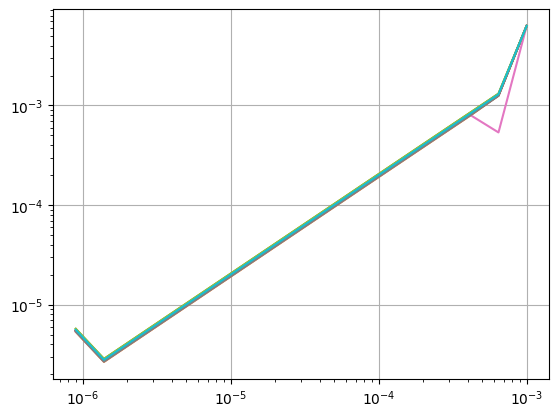

In [6]:
for i in range(10):
    plt.plot(stim_sam.physical_p, p_l[i])
plt.xscale('log')
plt.yscale('log')
plt.grid()

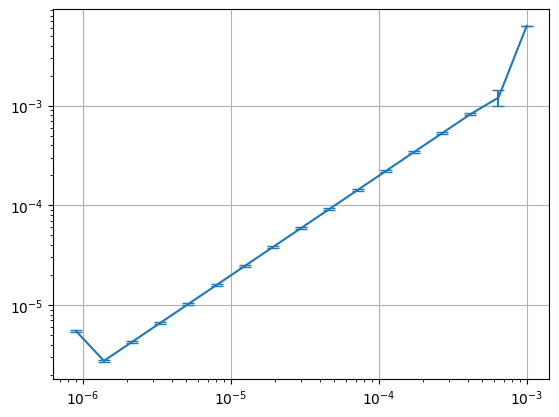

In [7]:
plt.errorbar(stim_sam.physical_p, np.average(p_l, axis=0), np.std(p_l, axis=0), capsize=4)
plt.xscale('log')
plt.yscale('log')
plt.grid()

100%|██████████| 16/16 [00:07<00:00,  2.06it/s]


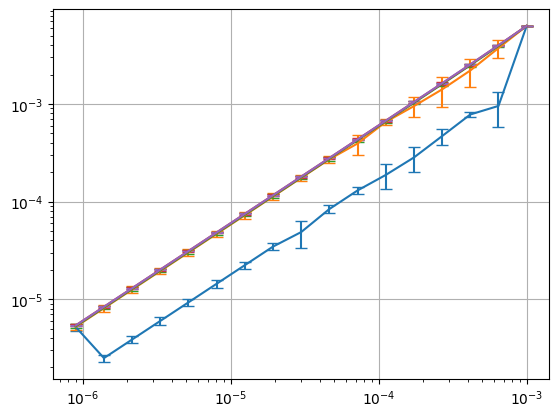

In [8]:
all_p = []
times = []

t = np.logspace(1,3,5)
for _t in t:
    p_l = []
    begin_time = time.time()
    for i in range(10):
        stim_sam.calculate_error(0.000001, _t)
        p_l.append([stim_sam.logical_p])
    end_time = time.time()
    times.append((end_time-begin_time)/10)

    p_l = np.array(p_l).reshape(10,-1)
    all_p.append(p_l)

    plt.errorbar(stim_sam.physical_p, np.average(p_l, axis=0), np.std(p_l, axis=0), capsize=4)
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.savefig('chain_length_png')

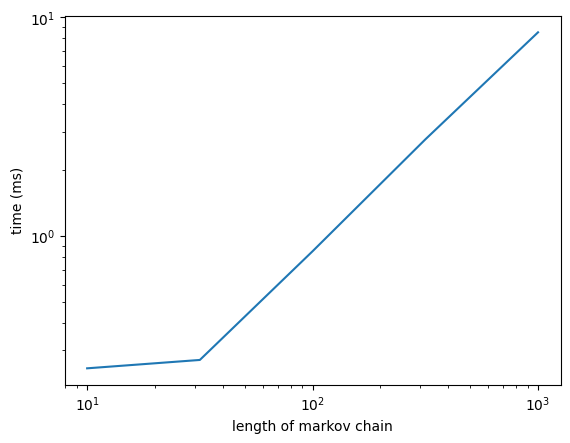

In [9]:
plt.plot(t, times)
plt.xlabel('length of markov chain')
plt.ylabel('time (ms)')
plt.xscale('log')
plt.yscale('log')
plt.savefig('splitting_times.png')

p=('1.00e-03',): 100%|██████████| 2000/2000 [00:00<00:00, 6129.15it/s]


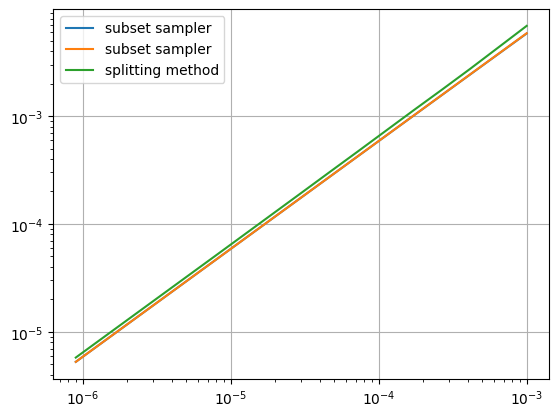

In [10]:
err_params = {'q': stim_sam.physical_p}

subset_sam = qs.SubsetSampler(protocol=rep, simulator=qs.StimSimulator,  p_max={'q': 0.001}, err_model=err_model, err_params=err_params, L=3)
subset_sam.run(2000)

v = subset_sam.stats()[0]
w = subset_sam.stats()[2]

plt.plot(stim_sam.physical_p, v, label = "subset sampler")
plt.plot(stim_sam.physical_p, w, label = "subset sampler")
plt.plot(stim_sam.physical_p, all_p[-1][-1], label = "splitting method")
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.savefig('repetition_splitting_vs_qsample.png')


In [11]:
times = []
for _t in t:
    begin = time.time()
    for i in range(10):
        subset_sam = qs.SubsetSampler(protocol=rep, simulator=qs.StimSimulator,  p_max={'q': 0.001}, err_model=err_model, err_params=err_params, L=3)
        subset_sam.run(int(_t))
        v = subset_sam.stats()[0]
        w = subset_sam.stats()[2]
    end = time.time()
    times.append((end-begin)/10)


p=('1.00e-03',): 100%|██████████| 1000/1000 [00:00<00:00, 9721.86it/s]


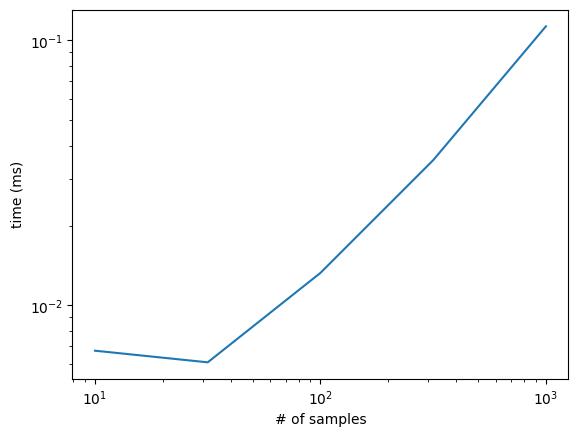

In [13]:
plt.plot(t, np.array(times))
plt.xlabel('# of samples')
plt.ylabel('time (ms)')
plt.xscale('log')
plt.yscale('log')
plt.savefig('qsample_times.png')

In [ ]:
# start writing latex document
# what takes the most time
# what causes the errors for short Markov chains
# implement some error correction
# figure out why it does this (fixing seed of random number) NOT OK
# find regime where it's advantageous

# think about lifetime measurements
# try to parallelize stuff 